# ANALISIS DE DATOS NULOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

penguin_color = {
    'Adelie': '#ff6602ff',
    'Gentoo': '#0f7175ff',
    'Chinstrap': '#c65dc9ff'
}

penguins_df = sns.load_dataset('penguins')
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# VERIFICAMOS SI EXITEN DATOS NULOS

In [ ]:
penguins_df.isnull()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
339,False,False,True,True,True,True,True
340,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False


# VERIFICAMOS QUE COLUMNAS TIENEN DATOS NUELOS

In [ ]:
penguins_df.isnull().any()

,0
species,False
island,False
bill_length_mm,True
bill_depth_mm,True
flipper_length_mm,True
body_mass_g,True
sex,True


# VERIFICAMOS CANTIDAD DE NULOS POR CADA VARIABLE

In [ ]:
penguins_df.isnull().sum().sort_values(ascending=False)

,0
sex,11
bill_depth_mm,2
bill_length_mm,2
flipper_length_mm,2
body_mass_g,2
island,0
species,0


# CUANTOS VALORES NULOS HAY EN TOTAL

In [ ]:
penguins_df.isnull().sum().sum()

np.int64(19)

# PROPORCIÓN DE DATOS NULOS CON RESPECTO AL TOTAL DEL DATASET

In [ ]:
plot_null_penguins = penguins_df.isnull().melt(value_name='missing')
plot_null_penguins

,variable,missing
0,species,False
1,species,False
2,species,False
3,species,False
4,species,False
...,...,...
2403,sex,True
2404,sex,False
2405,sex,False
2406,sex,False


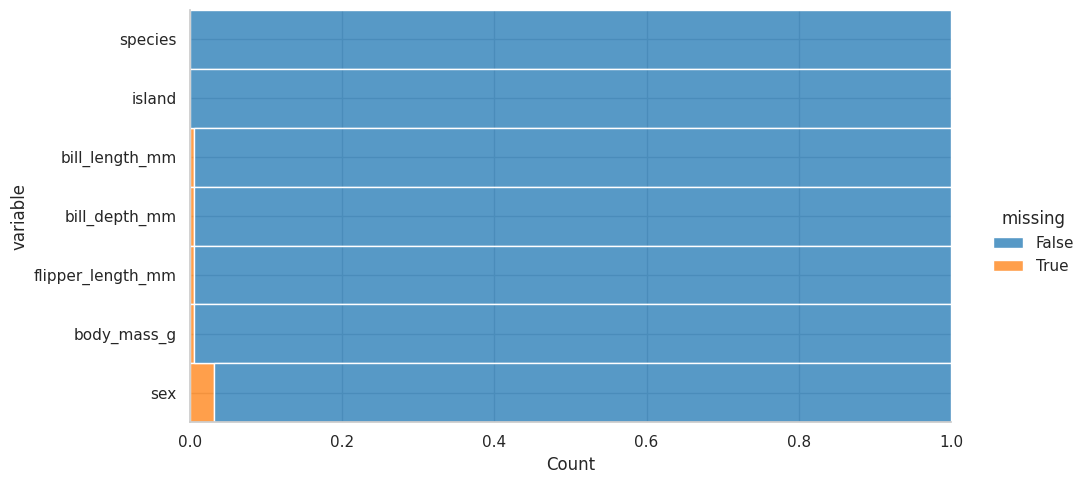

In [ ]:
sns.displot(data=plot_null_penguins,y='variable',hue='missing',aspect=2,multiple='fill')

# CUANDO LA PROPORCIÓN DE DATOS NULOS ES MUY PEQUEÑA CON RELACIÓN AL TOTAL DEL DATASET PODEMOS ELIMINAR LOS NULOS

In [ ]:
processed_penguins_df = (
    penguins_df
    .dropna()
    .reset_index(drop=True)
)
processed_penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
print(f'total dataset : {penguins_df.shape[0]}')
print(f'total despues de eliminar nulos :  {processed_penguins_df.shape[0]}')

total dataset : 344
total despues de eliminar nulos :  333


# QUE PASA CUANDO LA PROPORCIÓN DE NULOS ES MUY GRANDE

In [ ]:
titanic_df = sns.load_dataset('titanic')
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
titanic_df.isnull().sum().sum()

np.int64(869)

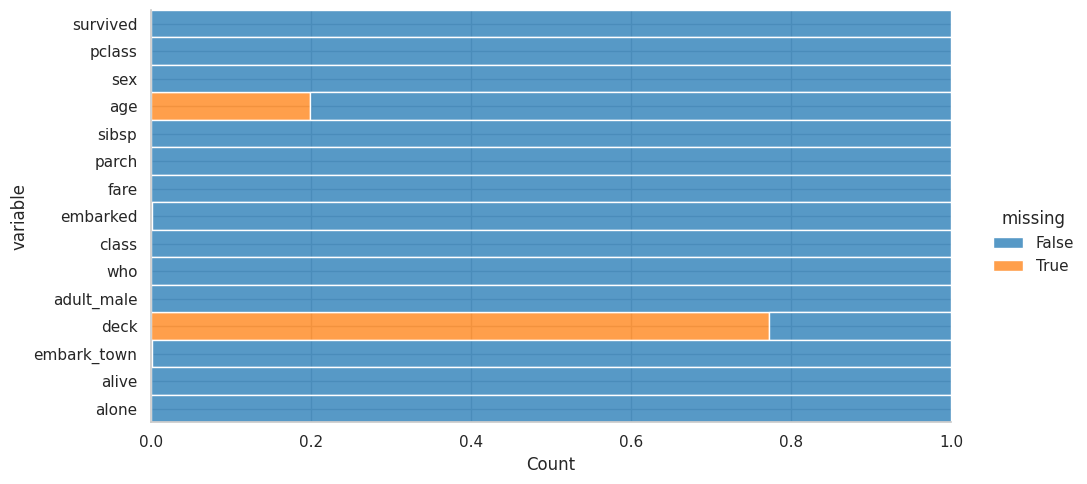

In [ ]:
plot_null_titanic = titanic_df.isnull().melt(value_name='missing')
sns.displot(data=plot_null_titanic,y='variable',hue='missing',aspect=2,multiple='fill')

In [ ]:
processed_titanic_df = (
    titanic_df
    .dropna()
    .reset_index(drop=True)
)
processed_titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
1,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
2,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
3,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
4,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
178,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
179,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
180,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [ ]:
print(f'total dataset : {titanic_df.shape[0]}')
print(f'total despues de eliminar nulos :  {processed_titanic_df.shape[0]}')

total dataset : 891
total despues de eliminar nulos :  182


# COMO SON MUCHOS CASOS CON LA VARIABLE DECK , ELIMINAMOS ESA VARIABLE

In [ ]:
df_titanic_no_deck = titanic_df.drop('deck', axis=1)
df_titanic_no_deck

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [ ]:
processed_titanic_no_deck_df = (
    df_titanic_no_deck
    .dropna()
    .reset_index(drop=True)
)
processed_titanic_no_deck_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,Queenstown,no,False
708,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
709,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
710,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True
